In [1]:
import numpy as np

# 1. 创建一个形状为3×4的随机矩阵X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("矩阵X:")
print(X)
print()

# 2. 创建一个形状为4×2的全1矩阵Y
Y = np.ones((4, 2))
print("矩阵Y:")
print(Y)
print()

# 3. 计算矩阵乘法Z=X×Y
Z = np.dot(X, Y)
print("矩阵Z=X×Y:")
print(Z)
print()

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及Z 的第2行所有元素
print("Z的第一行和第二列交叉处的元素:", Z[0, 1])
print("Z的第2行所有元素:", Z[1, :])
print()

# 5. 计算 Z 的Frobenius 范数
frobenius_norm = np.linalg.norm(Z)
print("Z的Frobenius范数:", frobenius_norm)


矩阵X:
[[-0.13191493 -0.69862579  0.66080814  1.13519526]
 [ 0.87777482  0.43848994 -0.45618612  0.2633085 ]
 [ 0.8726296   0.47431624 -0.32289389 -0.56783339]]

矩阵Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵Z=X×Y:
[[0.96546269 0.96546269]
 [1.12338713 1.12338713]
 [0.45621855 0.45621855]]

Z的第一行和第二列交叉处的元素: 0.9654626852324719
Z的第2行所有元素: [1.12338713 1.12338713]

Z的Frobenius范数: 2.1919179804918305


实际方差: 7.978900158974526e-06


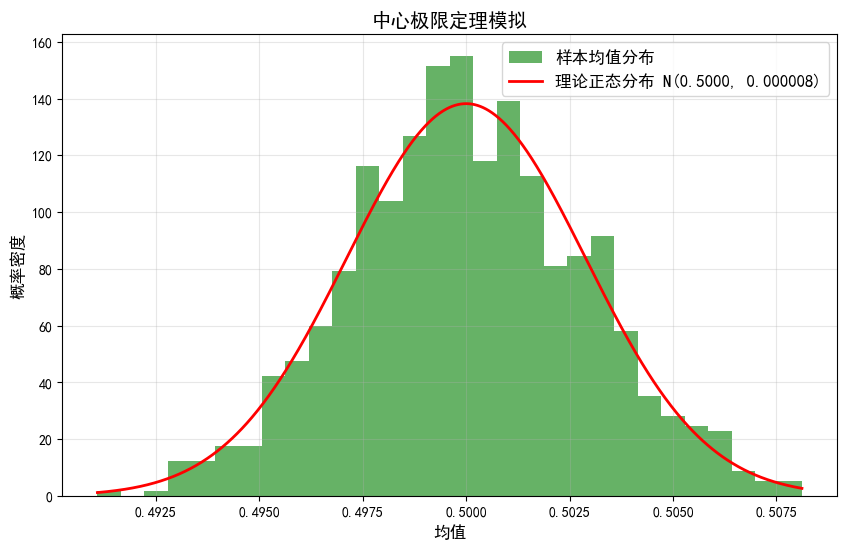

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置Matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置参数
n = 10000  # 每次生成的随机变量个数
m = 1000   # 重复次数

# 生成随机变量并计算均值
means = []
for _ in range(m):
    # 生成n个服从均匀分布U(0,1)的随机变量
    data = np.random.uniform(0, 1, n)
    # 计算均值并添加到列表
    means.append(np.mean(data))

# 将列表转换为numpy数组
means = np.array(means)

# 计算实际方差
actual_variance = np.var(means)
print(f"实际方差: {actual_variance}")

# 计算理论正态分布的参数
# 均匀分布U(0,1)的均值为0.5，方差为1/12
mu = 0.5  # 理论均值
sigma = np.sqrt(1/12 / n)  # 理论标准差（中心极限定理）

# 绘制直方图
plt.figure(figsize=(10, 6))
bins = 30
plt.hist(means, bins=bins, density=True, alpha=0.6, color='g', label='样本均值分布')

# 绘制理论正态分布的概率密度曲线
x = np.linspace(min(means), max(means), 1000)
y = norm.pdf(x, mu, sigma)
plt.plot(x, y, 'r-', lw=2, label=f'理论正态分布 N({mu:.4f}, {sigma**2:.6f})')

# 添加标题和标签
plt.title('中心极限定理模拟', fontsize=14)
plt.xlabel('均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 显示图形
plt.show()

In [3]:
import torch

# 定义前向计算函数
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b

# 手动计算梯度
def manual_gradient(x, w1, w2, a, b, L):
    # 计算L对b的梯度: dL/db = 2b
    dL_db = 2 * b
    
    # 计算b对a的梯度: db/da = 1
    db_da = 1
    
    # 计算b对w2的梯度: db/dw2 = 1
    db_dw2 = 1
    
    # 计算a对w1的梯度: da/dw1 = x
    da_dw1 = x
    
    # 链式法则计算L对w1的梯度: dL/dw1 = dL/db * db/da * da/dw1
    dL_dw1 = dL_db * db_da * da_dw1
    
    # 链式法则计算L对w2的梯度: dL/dw2 = dL/db * db/dw2
    dL_dw2 = dL_db * db_dw2
    
    return dL_dw1, dL_dw2

# 主函数
def main():
    # 给定参数值
    x = 2.0
    w1 = 1.5
    w2 = 0.5
    
    # 前向计算
    L, a, b = forward(x, w1, w2)
    print(f"前向计算结果:")
    print(f"a = x * w1 = {x} * {w1} = {a}")
    print(f"b = a + w2 = {a} + {w2} = {b}")
    print(f"L = b^2 = {b}^2 = {L}")
    print()
    
    # 手动计算梯度
    dL_dw1_manual, dL_dw2_manual = manual_gradient(x, w1, w2, a, b, L)
    print(f"手动计算梯度:")
    print(f"dL/dw1 = {dL_dw1_manual}")
    print(f"dL/dw2 = {dL_dw2_manual}")
    print()
    
    # 使用PyTorch自动微分
    x_torch = torch.tensor(x, requires_grad=False)
    w1_torch = torch.tensor(w1, requires_grad=True)
    w2_torch = torch.tensor(w2, requires_grad=True)
    
    # 前向计算
    a_torch = x_torch * w1_torch
    b_torch = a_torch + w2_torch
    L_torch = b_torch ** 2
    
    # 反向传播
    L_torch.backward()
    
    print(f"PyTorch自动微分结果:")
    print(f"dL/dw1 = {w1_torch.grad.item()}")
    print(f"dL/dw2 = {w2_torch.grad.item()}")
    print()
    
    # 验证结果是否一致
    print(f"验证结果:")
    print(f"dL/dw1 手动计算与PyTorch结果是否一致: {abs(dL_dw1_manual - w1_torch.grad.item()) < 1e-10}")
    print(f"dL/dw2 手动计算与PyTorch结果是否一致: {abs(dL_dw2_manual - w2_torch.grad.item()) < 1e-10}")

if __name__ == "__main__":
    main()


前向计算结果:
a = x * w1 = 2.0 * 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b^2 = 3.5^2 = 12.25

手动计算梯度:
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch自动微分结果:
dL/dw1 = 14.0
dL/dw2 = 7.0

验证结果:
dL/dw1 手动计算与PyTorch结果是否一致: True
dL/dw2 手动计算与PyTorch结果是否一致: True


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据集
digits = load_digits()
X = digits.data
y = digits.target

# 数据预处理
# 将图像展平为向量（这里已经是展平的，每个图像是8x8=64维向量）
# 对标签进行one-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 初始化参数
input_dim = X_train.shape[1]  # 64
hidden_dim = 10  # 10个类别

# 初始化权重和偏置
np.random.seed(42)
w = np.random.randn(input_dim, hidden_dim) * 0.01
b = np.zeros((1, hidden_dim))

# 超参数
batch_size = 32
learning_rate = 0.1
epochs = 50

# 实现softmax函数
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 实现交叉熵损失函数
def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-10)) / m
    return loss

# 训练模型
for epoch in range(epochs):
    # 随机打乱训练数据
    indices = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    # 小批量梯度下降
    for i in range(0, X_train.shape[0], batch_size):
        # 获取小批量数据
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        z = np.dot(X_batch, w) + b
        y_pred = softmax(z)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        
        # 反向传播
        dz = y_pred - y_batch
        dw = np.dot(X_batch.T, dz) / batch_size
        db = np.sum(dz, axis=0, keepdims=True) / batch_size
        
        # 更新参数
        w -= learning_rate * dw
        b -= learning_rate * db
    
    # 每10个epoch打印一次损失
    if (epoch + 1) % 10 == 0:
        # 计算整个训练集的损失
        z_train = np.dot(X_train, w) + b
        y_pred_train = softmax(z_train)
        train_loss = cross_entropy_loss(y_pred_train, y_train)
        print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")

# 测试模型
def predict(X):
    z = np.dot(X, w) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)

# 计算测试集上的准确率
y_pred_test = predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred_test == y_test_labels)
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 10, Loss: 1.3938
Epoch 20, Loss: 0.1594
Epoch 30, Loss: 0.0099
Epoch 40, Loss: 0.0011
Epoch 50, Loss: 0.0002
Test Accuracy: 0.9667


生成训练数据...
训练数据形状: X=(400, 2), y=(400,)

训练逻辑回归模型...
轮次 100, 损失: 0.4105
轮次 200, 损失: 0.3153
轮次 300, 损失: 0.2633
轮次 400, 损失: 0.2307
轮次 500, 损失: 0.2084
轮次 600, 损失: 0.1921
轮次 700, 损失: 0.1797
轮次 800, 损失: 0.1700
轮次 900, 损失: 0.1621
轮次 1000, 损失: 0.1555
训练后的参数: w=[0.86583324 0.87200318], b=-5.631190765326018

生成测试数据...
测试数据形状: X=(100, 2), y=(100,)

评估模型...
测试准确率: 0.9700

绘制决策边界...


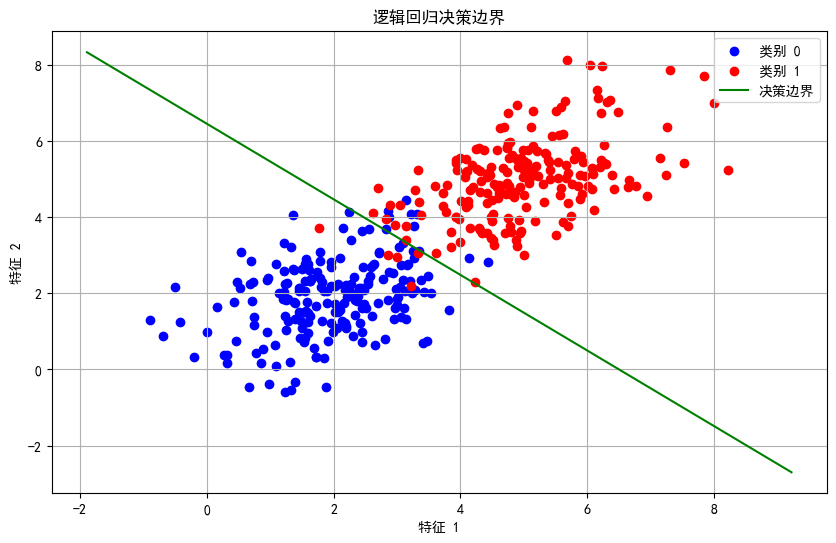

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 生成两类线性可分的数据
def generate_data(n_samples=200, n_features=2):
    # 第一类数据
    mean1 = [2, 2]
    cov1 = [[1, 0.5], [0.5, 1]]
    x1 = np.random.multivariate_normal(mean1, cov1, n_samples)
    y1 = np.zeros(n_samples, dtype=int)
    
    # 第二类数据
    mean2 = [5, 5]
    cov2 = [[1, 0.5], [0.5, 1]]
    x2 = np.random.multivariate_normal(mean2, cov2, n_samples)
    y2 = np.ones(n_samples, dtype=int)
    
    # 合并数据
    X = np.vstack((x1, x2))
    y = np.concatenate((y1, y2))
    
    # 打乱数据
    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]
    
    return X, y

# 2. 定义 sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. 定义二元交叉熵损失
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-10  # 避免log(0)
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

# 4. 实现梯度下降法训练逻辑回归模型
def train_logistic_regression(X, y, learning_rate=0.1, epochs=1000):
    n_samples, n_features = X.shape
    
    # 初始化参数
    w = np.zeros(n_features)
    b = 0
    
    # 训练过程
    for epoch in range(epochs):
        # 前向传播
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        
        # 计算梯度
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)
        
        # 更新参数
        w -= learning_rate * dw
        b -= learning_rate * db
        
        # 每100个轮次打印一次损失
        if (epoch + 1) % 100 == 0:
            loss = binary_cross_entropy(y, y_pred)
            print(f"轮次 {epoch+1}, 损失: {loss:.4f}")
    
    return w, b

# 5. 预测函数
def predict(X, w, b, threshold=0.5):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred >= threshold).astype(int)

# 6. 计算准确率
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

# 7. 绘制决策边界
def plot_decision_boundary(X, y, w, b):
    plt.figure(figsize=(10, 6))
    
    # 绘制数据点
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='类别 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='类别 1')
    
    # 绘制决策边界 (w1*x1 + w2*x2 + b = 0)
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    x2 = (-w[0] * x1 - b) / w[1]
    plt.plot(x1, x2, color='green', label='决策边界')
    
    plt.xlabel('特征 1')
    plt.ylabel('特征 2')
    plt.title('逻辑回归决策边界')
    plt.legend()
    plt.grid(True)
    plt.show()

# 8. 主函数
def main():
    # 生成训练数据
    print("生成训练数据...")
    X_train, y_train = generate_data()
    print(f"训练数据形状: X={X_train.shape}, y={y_train.shape}")
    
    # 训练模型
    print("\n训练逻辑回归模型...")
    w, b = train_logistic_regression(X_train, y_train)
    print(f"训练后的参数: w={w}, b={b}")
    
    # 生成测试数据
    print("\n生成测试数据...")
    X_test, y_test = generate_data(n_samples=50)  # 每类50个样本，共100个
    print(f"测试数据形状: X={X_test.shape}, y={y_test.shape}")
    
    # 评估模型
    print("\n评估模型...")
    y_pred = predict(X_test, w, b)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"测试准确率: {accuracy:.4f}")
    
    # 绘制决策边界
    print("\n绘制决策边界...")
    plot_decision_boundary(X_train, y_train, w, b)

if __name__ == "__main__":
    main()
